<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/SEMANA2/CodigoSemana2_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de MIMIC-IV

A continuación se muestran 4 bloques de código que sirven para la importación de la base de datos y las notas de MIMIC-IV dentro de este notebook. La forma de importación será mediante google drive, ya que MIMIC-IV es una base de datos muy grande y colab no lo soporta. El formato de importación es en 3 pasos:

1. Importar desde google drive
2. Ubicar el archivo zip dentro del drive
3. Descomprimir el archivo (Este paso se debe ejecutar siempre que se trabaje con este notebook)

In [2]:
#Importar la base de datos de MIMIC-IV
#Se importará desde google drive, ya que la base de datos es muy grande y colab no soporta tanto peso

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Se listan solo las tablas de la base de datos de mimic MIMIC-IV que se usarán en el proyecto.

!find /content/drive/MyDrive -maxdepth 4 -type f \
    \( -name "patients.csv.gz" \
       -o -name "admissions.csv.gz" \
       -o -name "diagnoses_icd.csv.gz" \
       -o -name "d_icd_diagnoses.csv.gz" \
       -o -name "prescriptions.csv.gz" \
       -o -name "icustays.csv.gz" \
       -o -name "radiology.csv.gz" \)

/content/drive/MyDrive/patients.csv.gz
/content/drive/MyDrive/admissions.csv.gz
/content/drive/MyDrive/diagnoses_icd.csv.gz
/content/drive/MyDrive/d_icd_diagnoses.csv.gz
/content/drive/MyDrive/prescriptions.csv.gz
/content/drive/MyDrive/icustays.csv.gz
/content/drive/MyDrive/radiology.csv.gz


In [4]:
#Se crea la estructura mínima de MIMIC-IV con las tablas usadas
#Directorios locales mínimos
!rm -rf /content/mimiciv_used
!mkdir -p /content/mimiciv_used/hosp
!mkdir -p /content/mimiciv_used/icu
!mkdir -p /content/mimiciv_used/notes

In [5]:
#Bloque para copiar tablas desde drive
#Limpiar y crear estructura mínima local
!rm -rf /content/mimiciv_used
!mkdir -p /content/mimiciv_used/hosp
!mkdir -p /content/mimiciv_used/icu
!mkdir -p /content/mimiciv_used/notes

#HOSP
!cp /content/drive/MyDrive/patients.csv.gz        /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/admissions.csv.gz      /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/diagnoses_icd.csv.gz   /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/d_icd_diagnoses.csv.gz /content/mimiciv_used/hosp/
!cp /content/drive/MyDrive/prescriptions.csv.gz   /content/mimiciv_used/hosp/

#ICU
!cp /content/drive/MyDrive/icustays.csv.gz        /content/mimiciv_used/icu/

#NOTES
!cp /content/drive/MyDrive/radiology.csv.gz       /content/mimiciv_used/notes/

#Verificación OBLIGATORIA
!echo "=== HOSP ==="
!ls -lh /content/mimiciv_used/hosp

!echo "=== ICU ==="
!ls -lh /content/mimiciv_used/icu

!echo "=== NOTES ==="
!ls -lh /content/mimiciv_used/notes

=== HOSP ===
total 633M
-rw------- 1 root root  20M Jan 16 18:46 admissions.csv.gz
-rw------- 1 root root  33M Jan 16 18:46 diagnoses_icd.csv.gz
-rw------- 1 root root 856K Jan 16 18:46 d_icd_diagnoses.csv.gz
-rw------- 1 root root 2.8M Jan 16 18:46 patients.csv.gz
-rw------- 1 root root 579M Jan 16 18:46 prescriptions.csv.gz
=== ICU ===
total 3.2M
-rw------- 1 root root 3.2M Jan 16 18:46 icustays.csv.gz
=== NOTES ===
total 746M
-rw------- 1 root root 746M Jan 16 18:46 radiology.csv.gz


In [6]:
#Se definen las rutas de trabajo

BASE_PATH = "/content/mimiciv_used" #Ruta base

HOSP_PATH  = f"{BASE_PATH}/hosp" #Ruta módulo hospital
ICU_PATH   = f"{BASE_PATH}/icu" #Ruta módulo icu
NOTES_PATH = f"{BASE_PATH}/notes" #Ruta módulo notas

#Ver resultados
print("Rutas configuradas:")
print("HOSP :", HOSP_PATH)
print("ICU  :", ICU_PATH)
print("NOTES:", NOTES_PATH)

Rutas configuradas:
HOSP : /content/mimiciv_used/hosp
ICU  : /content/mimiciv_used/icu
NOTES: /content/mimiciv_used/notes


# Análisis de MIMIC-IV

Se hará un análisis para inspeccionar y entender que hay dentro de la base de datos de MIMIC-IV. Para ello, se usarán funciones de Python para saber que contiene cada módulo (hosp-icu). A su vez, se verán las tablas más importante que tienen, las cuales son:

* Hosp -> patients, admissions
* Icu -> icustays

In [7]:
#Importación de librerías

import os #Se importa os para interactuar con el sistema operativo y así manejar archivos
import pandas as pd

!pip -q install scikit-survival

import numpy as np
import matplotlib.pyplot as plt

from sksurv.nonparametric import kaplan_meier_estimator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 16.2 MB/s eta 0:00:00


In [8]:
#En este bloque se definen las rutas base del dataset MIMIC-IV, usando solo las tablas necesarias

BASE_PATH = "/content/mimiciv_used"

HOSP_DIR  = os.path.join(BASE_PATH, "hosp") #Tablas hospitalarias
ICU_DIR   = os.path.join(BASE_PATH, "icu") #Tablas UCI
NOTES_DIR = os.path.join(BASE_PATH, "notes") #Notas clínicas (texto libre)

#Función para cargar tablas del módulo HOSP
#Se seleccionan solo columnas específicas para así optimizar memoria
def load_hosp(table, usecols=None):
    path = os.path.join(HOSP_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

#Función para cargar tablas del módulo ICU
def load_icu(table, usecols=None):
    path = os.path.join(ICU_DIR, f"{table}.csv.gz")
    return pd.read_csv(path, compression="gzip", usecols=usecols)

In [9]:
#Se carga la tabla "patients" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

patients = load_hosp(
    "patients",
    usecols=["subject_id", "gender", "anchor_age", "anchor_year"]
)

#Análisis para la tabla patients

print("patients shape:", patients.shape)
print("\nColumnas:", patients.columns.tolist())
print("\nDtypes:")
print(patients.dtypes)
print("\nHead:")
patients.head() #Ver los primeros datos

patients shape: (364627, 4)

Columnas: ['subject_id', 'gender', 'anchor_age', 'anchor_year']

Dtypes:
subject_id      int64
gender         object
anchor_age      int64
anchor_year     int64
dtype: object

Head:


,subject_id,gender,anchor_age,anchor_year
0,10000032,F,52,2180
1,10000048,F,23,2126
2,10000058,F,33,2168
3,10000068,F,19,2160
4,10000084,M,72,2160


In [10]:
#Se carga la tabla "admissions" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

admissions = load_hosp(
    "admissions",
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "hospital_expire_flag"
    ]
)

print("admissions shape:", admissions.shape)
print("\nColumnas:", admissions.columns.tolist())
print("\nDtypes:")
print(admissions.dtypes)
print("\nHead:")
admissions.head()

admissions shape: (546028, 6)

Columnas: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'hospital_expire_flag']

Dtypes:
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
hospital_expire_flag     int64
dtype: object

Head:


,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,0


In [11]:
#Se carga la tabla "icustays" que pertenece a icu
#Se seleccionan solo las columnas relevantes para el análisis demográfico

icustays = load_icu(
    "icustays",
    usecols=[
        "subject_id",
        "hadm_id",
        "stay_id",
        "intime",
        "outtime"
    ]
)

print("icustays shape:", icustays.shape)
print("\nColumnas:", icustays.columns.tolist())
print("\nDtypes:")
print(icustays.dtypes)
print("\nHead:")
icustays.head()

icustays shape: (94458, 5)

Columnas: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']

Dtypes:
subject_id     int64
hadm_id        int64
stay_id        int64
intime        object
outtime       object
dtype: object

Head:


,subject_id,hadm_id,stay_id,intime,outtime
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41


In [12]:
#Se carga la tabla "diagnoses" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

diagnoses = load_hosp(
    "diagnoses_icd",
    usecols=[
        "subject_id",
        "hadm_id",
        "seq_num",
        "icd_code",
        "icd_version"
    ]
)

print("diagnoses shape:", diagnoses.shape)
print("\nColumnas:", diagnoses.columns.tolist())
print("\nDtypes:")
print(diagnoses.dtypes)
print("\nHead:")
display(diagnoses.head())

diagnoses shape: (6364488, 5)

Columnas: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']

Dtypes:
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object

Head:


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [13]:
#Se carga la tabla "d_icd_diagnoses" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

icd_dict = load_hosp(
    "d_icd_diagnoses",
    usecols=[
        "icd_code",
        "icd_version",
        "long_title"
    ]
)

print("icd_dict shape:", icd_dict.shape)
print("\nColumnas:", icd_dict.columns.tolist())
print("\nDtypes:")
print(icd_dict.dtypes)
print("\nHead:")
display(icd_dict.head())

icd_dict shape: (112107, 3)

Columnas: ['icd_code', 'icd_version', 'long_title']

Dtypes:
icd_code       object
icd_version     int64
long_title     object
dtype: object

Head:


,icd_code,icd_version,long_title
0,0010,9,Cholera due to vibrio cholerae
1,0011,9,Cholera due to vibrio cholerae el tor
2,0019,9,"Cholera, unspecified"
3,0020,9,Typhoid fever
4,0021,9,Paratyphoid fever A


In [14]:
#Se carga la tabla "prescriptions" que pertenece a hosp
#Se seleccionan solo las columnas relevantes para el análisis demográfico

prescriptions = load_hosp(
    "prescriptions",
    usecols=[
        "subject_id",
        "hadm_id",
        "starttime",
        "stoptime",
        "drug"
    ]
)

print("prescriptions shape:", prescriptions.shape)
print("\nColumnas:", prescriptions.columns.tolist())
print("\nDtypes:")
print(prescriptions.dtypes)
print("\nHead:")
display(prescriptions.head())

prescriptions shape: (20292611, 5)

Columnas: ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']

Dtypes:
subject_id     int64
hadm_id        int64
starttime     object
stoptime      object
drug          object
dtype: object

Head:


,subject_id,hadm_id,starttime,stoptime,drug
0,10000032,22595853,2180-05-08 08:00:00,2180-05-07 22:00:00,Furosemide
1,10000032,22595853,2180-05-07 02:00:00,2180-05-07 22:00:00,Ipratropium Bromide Neb
2,10000032,22595853,2180-05-07 01:00:00,2180-05-07 09:00:00,Furosemide
3,10000032,22595853,2180-05-07 01:00:00,2180-05-07 01:00:00,Potassium Chloride
4,10000032,22595853,2180-05-07 00:00:00,2180-05-07 22:00:00,Sodium Chloride 0.9% Flush




---



Ahora corresponde el análisis para inspeccionar y entender que hay dentro de las notas de MIMIC-IV. Dentro de estas notas se tienen 4 carpetas, las cuales son:

* discharge -> resumen del alta de los pacientes
* radiology -> texto de informes radiológicos
* discharge_detail -> lo mismo que discharge pero normalizado
* radiology_detail -> lo mismo que radiology pero normalizado

Se usará radiology.csv.gz porque tiene los datos útiles para trabajar, como hadm_id, timestap y muchas radiografías que se hacen en las primeras horas.

In [15]:
#Se carga la tabla "radiology" que pertenece a las notas de texto de mimic-iv
#Se seleccionan solo las columnas relevantes para el análisis demográfico

# radiology NO está en HOSP ni ICU, está en NOTES_DIR
radiology_path = os.path.join(NOTES_DIR, "radiology.csv.gz")

radiology = pd.read_csv(
    radiology_path,
    compression="gzip",
    usecols=["subject_id", "hadm_id", "charttime", "text"]
)

print("radiology shape:", radiology.shape)
print("\nColumnas:", radiology.columns.tolist())
print("\nDtypes:")
print(radiology.dtypes)
print("\nHead:")
display(radiology.head())

radiology shape: (2321355, 4)

Columnas: ['subject_id', 'hadm_id', 'charttime', 'text']

Dtypes:
subject_id      int64
hadm_id       float64
charttime      object
text           object
dtype: object

Head:


,subject_id,hadm_id,charttime,text
0,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032,22595853.0,2180-05-06 23:00:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032,NaN,2180-06-03 12:46:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032,NaN,2180-07-08 13:18:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...


# Filtrado de la población geriátrica

La idea de esta sección es generar la cohorte base, seleccionando a los pacientes de tercera edad, es decir con 60+ años. Todo esto se hará desde los módulos hosp e icu de MIMIC-IV

In [16]:
#Convertir las columnas de tiempo en la tabla admissions al formato datetime
for col in ["admittime", "dischtime", "deathtime"]:
    admissions[col] = pd.to_datetime(admissions[col], errors="coerce")

#Convertir las columnas de tiempo en la tabla icustays al formato datetime
for col in ["intime", "outtime"]:
    icustays[col] = pd.to_datetime(icustays[col], errors="coerce")

In [17]:
#Se une admissions con patients, todo esto usando subject_id
#Esto permite tener en una misma tabla los tiempos de hospitalización y las variables para calcular edad
cohort_hosp = admissions.merge(
    patients,
    on="subject_id",
    how="inner",
    validate="many_to_one" #many_to_one garantiza que cada subject_id en patients aparezca como máximo una vez
)                          #Esto es útil ya que en admissions puede aparecer muchas veces (un paciente puede tener varias hospitalizaciones).

cohort_hosp["admit_year"] = cohort_hosp["admittime"].dt.year #Extrae el año de admisión (hospitalización) a partir de admittime
cohort_hosp["age_at_admit"] = cohort_hosp["anchor_age"] + (cohort_hosp["admit_year"] - cohort_hosp["anchor_year"]) #Estima la edad al momento de la admisión
                                                                                                                  #Se ajuste la diferencia de años entre anchor_age y anchor_year
cohort_hosp_60 = cohort_hosp.loc[cohort_hosp["age_at_admit"] >= 60].copy() #Se filtran los pacientes que ingresen y tengan 60+ años

#Se verifican los tamaños antes y después del filtrado
print("Cohorte HOSP total:", cohort_hosp.shape)
print("Cohorte HOSP 60+   :", cohort_hosp_60.shape)

#Muestra las columnas relevantes de la cohorte geriátrica para analizar visualmente
cohort_hosp_60[["subject_id","hadm_id","gender","age_at_admit","admittime","dischtime","hospital_expire_flag"]].head()

Cohorte HOSP total: (546028, 11)
Cohorte HOSP 60+   : (287702, 11)


,subject_id,hadm_id,gender,age_at_admit,admittime,dischtime,hospital_expire_flag
5,10000084,23052089,M,72,2160-11-21 01:56:00,2160-11-25 14:52:00,0
6,10000084,29888819,M,72,2160-12-28 05:11:00,2160-12-28 16:07:00,0
10,10000161,22148160,M,60,2163-08-20 01:42:00,2163-08-20 16:33:00,0
14,10000635,20642640,F,81,2143-12-23 14:55:00,2143-12-24 12:52:00,0
15,10000635,26134563,F,74,2136-06-19 14:24:00,2136-06-20 11:30:00,0


In [18]:
#Colapsar a nivel paciente: dejar SOLO la ÚLTIMA hospitalización geriátrica por subject_id
cohort_hosp_60 = cohort_hosp_60.sort_values(["subject_id", "admittime"])

cohort_hosp_60 = (
    cohort_hosp_60
    .groupby("subject_id", as_index=False)
    .last()
)

print("Filas (pacientes 60+):", cohort_hosp_60.shape[0])
print("subject_id únicos     :", cohort_hosp_60["subject_id"].nunique())

Filas (pacientes 60+): 111122
subject_id únicos     : 111122


In [19]:
#Checks básicos de cohorte

#Printeos para análisis
print("Edad mínima (HOSP 60+):", cohort_hosp_60["age_at_admit"].min())
print("Edad máxima (HOSP 60+):", cohort_hosp_60["age_at_admit"].max())

print("Pacientes únicos (subject_id) en HOSP 60+:",
      cohort_hosp_60["subject_id"].nunique())

print("Mortalidad (hospital_expire_flag) en HOSP 60+:",
      cohort_hosp_60["hospital_expire_flag"].mean())

Edad mínima (HOSP 60+): 60
Edad máxima (HOSP 60+): 106
Pacientes únicos (subject_id) en HOSP 60+: 111122
Mortalidad (hospital_expire_flag) en HOSP 60+: 0.08426774176130739


In [21]:
#Comprueba que un DataFrame tenga exactamente una fila por paciente (subject_id)
#Si hay duplicados, lanza un error para detener el pipeline
def check_unique(df, key="subject_id", name="df"):
    n_rows = len(df) #Número total de filas
    n_uniq = df[key].nunique(dropna=False) #Número de IDs únicos
    print(f"[{name}] filas={n_rows:,} | {key} únicos={n_uniq:,}")

    #1 fila = 1 paciente
    assert n_rows == n_uniq, (
        f"{name} NO es 1 fila por {key}. "
        f"Duplicados: {n_rows - n_uniq:,}"
    )
    print(f"OK: {name} es 1 fila por {key}\n")

#Esta tabla representa la cohorte final a nivel paciente
#A partir de aquí, todas las fases que vienen deben mantener esta unicidad
base_patient = cohort_hosp_60.copy()

#Garantiza que la cohorte ya esté correctamente colapsada a 1 fila por paciente
check_unique(base_patient, key="subject_id", name="base_patient")

#Subconjunto de columnas necesarias para unir (merge) información de otras fases como diagnósticos, notas clínicas o supervivencia
base_keys = base_patient[["subject_id", "hadm_id", "admittime"]].copy()

#Asegurar formato datetime para cálculos temporales que vienen después
base_keys["admittime"] = pd.to_datetime(base_keys["admittime"], errors="coerce")

[base_patient] filas=111,122 | subject_id únicos=111,122
OK: base_patient es 1 fila por subject_id



In [22]:
#Guardar resultados

OUT_DIR = "/content/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

base_patient.to_parquet(
    os.path.join(OUT_DIR, "cohort_hosp_60.parquet"),
    index=False
)

print("Cohorte (base_patient) guardada en:", OUT_DIR)

Cohorte (base_patient) guardada en: /content/outputs


age_at_admit
60–70    43437
71–80    33962
81+      33723
Name: count, dtype: int64


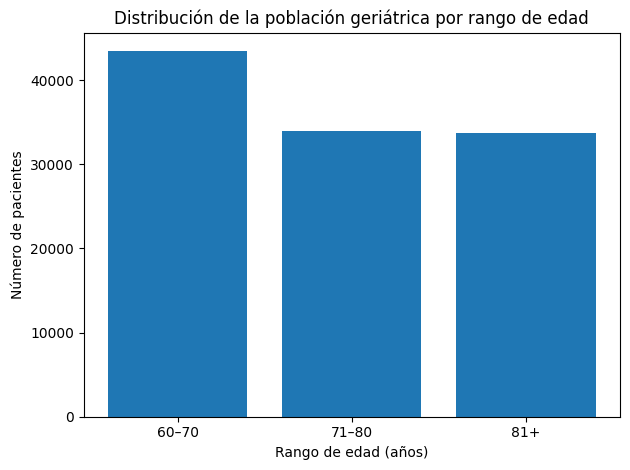

In [23]:
#Gráfico para ver las diversas edades dentro de la población geriátrica

#Definir rangos de edad
bins = [60, 70, 80, 120]
labels = ["60–70", "71–80", "81+"]

#Crear variable categórica de edad
age_groups = pd.cut(
    base_patient["age_at_admit"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

#Contar pacientes por rango
age_counts = age_groups.value_counts().sort_index()

print(age_counts)

#Gráfico
plt.figure()
plt.bar(age_counts.index, age_counts.values)
plt.xlabel("Rango de edad (años)")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la población geriátrica por rango de edad")
plt.tight_layout()
plt.show()

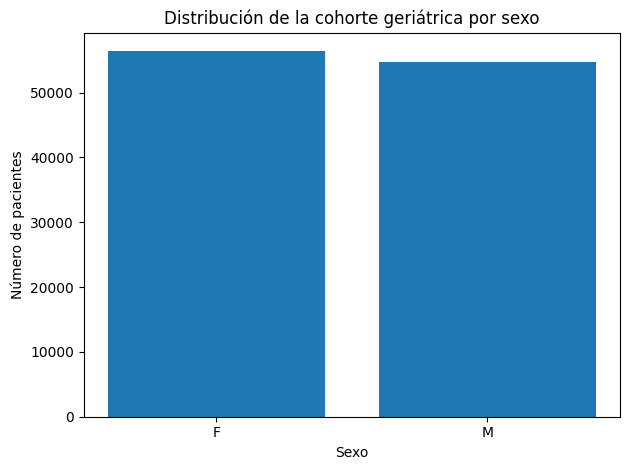

In [24]:
#Gráfico para ver la distribución por sexo

sex_counts = base_patient["gender"].value_counts()

plt.figure()
plt.bar(sex_counts.index, sex_counts.values)
plt.xlabel("Sexo")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la cohorte geriátrica por sexo")
plt.tight_layout()
plt.show()

# Integración del historial clínico

En esta sección se cargarán las tablas de diagnósticos clínicos y su diccionario asociado. Esto permitirá la identificación de los antecedentes médicos de cada hospitalización. A su vez se integrarán los antecedentes médicos a la cohorte geriátrica hospitalaria. Cada hospitalización quedará asociada a sus diagnósticos clínicos, con una descripción del diagnóstico. También se cargarán las prescripciones farmacológicas registradas durante las hospitalizaciones. Por último, se integrarán los medicamentos a la cohorte geriátrica, considerando solo las prescripciones iniciadas dentro de las primeras 24 horas desde la admisión hospitalaria. La idea de esto es representar la exposición farmacológica al ingreso. Además, se almacenarán los datasets resultantes de diagnósticos y medicamentos en formato Parquet, lo que permite asegurar la reproducibilidad del análisis y no recalcular los datos.

In [25]:
#Unir diagnósticos a la cohorte base usando subject_id y hadm_id
dx_idx = base_keys.merge(
    diagnoses,
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_many" #Un paciente/hospitalización puede tener múltiples diagnósticos
)

#Agregar la descripción clínica de cada código ICD usando el diccionario
dx_idx = dx_idx.merge(
    icd_dict,
    on=["icd_code", "icd_version"],
    how="left",
    validate="many_to_one" #Cada código ICD tiene una única descripción
)

#Se eliminan diagnósticos sin código ICD válido o sin descripción clínica
dx_clean = dx_idx.dropna(
    subset=["icd_code", "long_title"]
).copy()

#Verificación de tamaños antes y después de la limpieza
print("dx_idx   :", dx_idx.shape)
print("dx_clean :", dx_clean.shape)

#Vista rápida de diagnósticos clínicos limpios
dx_clean[["subject_id", "hadm_id", "icd_code", "long_title"]].head()

dx_idx   : (1595949, 7)
dx_clean : (1595872, 7)


,subject_id,hadm_id,icd_code,long_title
0,10000084,29888819,R4182,"Altered mental status, unspecified"
1,10000084,29888819,G20,Parkinson's disease
2,10000084,29888819,F0280,Dementia in other diseases classified elsewher...
3,10000084,29888819,R609,"Edema, unspecified"
4,10000084,29888819,E785,"Hyperlipidemia, unspecified"


In [28]:
#Se cuenta el número de diagnósticos ICD distintos asociados a la hospitalización índice de cada paciente
dx_features_patient = (
    dx_clean[["subject_id", "icd_code"]]
    .drop_duplicates()              # Evita contar el mismo diagnóstico más de una vez
    .groupby("subject_id", as_index=False)
    .agg(
        n_unique_dx=("icd_code", "nunique")  # Número de diagnósticos clínicos distintos
    )
)

#Verificación del tamaño del dataset que quedó
print("dx_features_patient:", dx_features_patient.shape)

#Garantiza que el dataset esté colapsado correctamente a 1 fila por paciente
check_unique(dx_features_patient, key="subject_id", name="dx_features_patient")

#Vista rápida para ver como quedó
dx_features_patient.head()

dx_features_patient: (111045, 2)
[dx_features_patient] filas=111,045 | subject_id únicos=111,045
OK: dx_features_patient es 1 fila por subject_id



,subject_id,n_unique_dx
0,10000084,6
1,10000161,2
2,10000635,9
3,10000690,17
4,10000764,19


In [29]:
#RX primeras 24h (índice), esto con las features por paciente

#Esto es para aegurar tipos datetime para poder filtrar correctamente en 0–24h
prescriptions["starttime"] = pd.to_datetime(prescriptions["starttime"], errors="coerce")
prescriptions["stoptime"]  = pd.to_datetime(prescriptions["stoptime"], errors="coerce")

#Unir prescripciones con la hospitalización índice para obtener el admittime y así calcular la ventana de 24h por paciente
rx_idx = prescriptions.merge(
    base_keys[["subject_id", "hadm_id", "admittime"]],
    on=["subject_id", "hadm_id"],
    how="inner",
    validate="many_to_one"  # múltiples RX por (subject_id, hadm_id), pero un único admittime en base_keys
)

#Filtrar prescripciones que inicia en las primeras 24 horas
#Se usa starttime como criterio
rx_24h = rx_idx.loc[
    rx_idx["starttime"].notna() &
    (rx_idx["starttime"] >= rx_idx["admittime"]) &
    (rx_idx["starttime"] <= rx_idx["admittime"] + pd.Timedelta(hours=24))
].copy()

print("rx_24h:", rx_24h.shape)

#Feature a nivel paciente
#Número de fármacos distintos administrados en las primeras 24h
#Se elimina duplicación para no contar el mismo medicamento más de una vez
rx_features_patient = (
    rx_24h[["subject_id", "drug"]]
    .dropna()                 # elimina filas sin nombre de fármaco
    .drop_duplicates()        # evita sobrecontar el mismo drug dentro de un paciente
    .groupby("subject_id", as_index=False)
    .agg(n_unique_drugs_24h=("drug", "nunique"))
)

print("rx_features_patient:", rx_features_patient.shape)

#Validación para ver si queda 1 fila por subject_id
check_unique(rx_features_patient, key="subject_id", name="rx_features_patient")

#Vista rápida
rx_features_patient.head()

rx_24h: (2176696, 6)
rx_features_patient: (99393, 2)
[rx_features_patient] filas=99,393 | subject_id únicos=99,393
OK: rx_features_patient es 1 fila por subject_id



,subject_id,n_unique_drugs_24h
0,10000690,13
1,10000764,8
2,10000947,10
3,10000980,19
4,10001176,23


In [30]:
#Último fármaco en 24h (1 por subject_id)

rx_24h_sorted = rx_24h.sort_values(["subject_id", "starttime"]).copy()

rx_last_24h_patient = (
    rx_24h_sorted
    .groupby("subject_id", as_index=False)
    .last()[["subject_id", "drug", "starttime"]]
    .rename(columns={"drug": "last_drug_24h", "starttime": "last_drug_time_24h"})
)

#Vista rápida
print("rx_last_24h_patient:", rx_last_24h_patient.shape)
check_unique(rx_last_24h_patient, key="subject_id", name="rx_last_24h_patient")
rx_last_24h_patient.head()

rx_last_24h_patient: (99393, 3)
[rx_last_24h_patient] filas=99,393 | subject_id únicos=99,393
OK: rx_last_24h_patient es 1 fila por subject_id



,subject_id,last_drug_24h,last_drug_time_24h
0,10000690,Morphine Sulfate,2152-01-29 21:00:00
1,10000764,TraMADOL (Ultram),2132-10-15 20:00:00
2,10000947,Lisinopril,2121-05-10 08:00:00
3,10000980,Furosemide,2193-08-15 23:00:00
4,10001176,Insulin,2186-11-29 22:00:00


In [31]:
#ICU features por paciente (1 fila por subject_id)

icu_idx = base_keys.merge(
    icustays[["subject_id", "hadm_id", "stay_id", "intime", "outtime"]],
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_many"
)

#Flag para ver si tuvo UCI en la hospitalización índice
icu_any = (
    icu_idx[["subject_id", "stay_id"]]
    .assign(icu_any=lambda d: d["stay_id"].notna().astype(int))
    .groupby("subject_id", as_index=False)
    .agg(icu_any=("icu_any", "max"),
         n_icu_stays=("stay_id", "nunique"))
)

#LOS UCI (días) por paciente (si hay múltiples stays, suma)
icu_idx["icu_los_days"] = (
    (icu_idx["outtime"] - icu_idx["intime"]).dt.total_seconds() / (3600 * 24)
)

icu_los = (
    icu_idx.groupby("subject_id", as_index=False)
    .agg(icu_los_days=("icu_los_days", "sum"))
)

icu_features_patient = icu_any.merge(icu_los, on="subject_id", how="left", validate="one_to_one")
icu_features_patient["icu_los_days"] = icu_features_patient["icu_los_days"].fillna(0)

print("icu_features_patient:", icu_features_patient.shape)
check_unique(icu_features_patient, key="subject_id", name="icu_features_patient")
icu_features_patient.head()

icu_features_patient: (111122, 4)
[icu_features_patient] filas=111,122 | subject_id únicos=111,122
OK: icu_features_patient es 1 fila por subject_id



,subject_id,icu_any,n_icu_stays,icu_los_days
0,10000084,0,0,0.0
1,10000161,0,0,0.0
2,10000635,0,0,0.0
3,10000690,0,0,0.0
4,10000764,0,0,0.0


In [32]:
#Integración final (1 fila por subject_id)

patient_history = (
    base_patient
    .merge(dx_features_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(rx_features_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(rx_last_24h_patient, on="subject_id", how="left", validate="one_to_one")
    .merge(icu_features_patient, on="subject_id", how="left", validate="one_to_one")
)

#Rellenos
patient_history["n_unique_dx"] = patient_history["n_unique_dx"].fillna(0).astype(int)
patient_history["n_unique_drugs_24h"] = patient_history["n_unique_drugs_24h"].fillna(0).astype(int)
patient_history["icu_any"] = patient_history["icu_any"].fillna(0).astype(int)
patient_history["n_icu_stays"] = patient_history["n_icu_stays"].fillna(0).astype(int)
patient_history["icu_los_days"] = patient_history["icu_los_days"].fillna(0)

print("patient_history:", patient_history.shape)
check_unique(patient_history, key="subject_id", name="patient_history")

patient_history.head()

patient_history: (111122, 18)
[patient_history] filas=111,122 | subject_id únicos=111,122
OK: patient_history es 1 fila por subject_id



,subject_id,hadm_id,admittime,dischtime,deathtime,hospital_expire_flag,gender,anchor_age,anchor_year,admit_year,age_at_admit,n_unique_dx,n_unique_drugs_24h,last_drug_24h,last_drug_time_24h,icu_any,n_icu_stays,icu_los_days
0,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,NaT,0,M,72,2160,2160,72,6,0,NaN,NaT,0,0,0.0
1,10000161,22148160,2163-08-20 01:42:00,2163-08-20 16:33:00,NaT,0,M,60,2163,2163,60,2,0,NaN,NaT,0,0,0.0
2,10000635,20642640,2143-12-23 14:55:00,2143-12-24 12:52:00,NaT,0,F,74,2136,2143,81,9,0,NaN,NaT,0,0,0.0
3,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaT,0,F,86,2150,2152,88,17,13,Morphine Sulfate,2152-01-29 21:00:00,0,0,0.0
4,10000764,27897940,2132-10-14 23:31:00,2132-10-19 16:30:00,NaT,0,M,86,2132,2132,86,19,8,TraMADOL (Ultram),2132-10-15 20:00:00,0,0,0.0


In [34]:
#Guardar outputs

patient_history.to_parquet(
    os.path.join(OUT_DIR, "patient_history.parquet"),
    index=False
)

#Esto es opcional, y es para guardar dx_clean y rx_24h como intermedios “largos”, en caso de necesitarlos
dx_clean.to_parquet(os.path.join(OUT_DIR, "dx_clean_index.parquet"), index=False)
rx_24h.to_parquet(os.path.join(OUT_DIR, "rx_24h_index.parquet"), index=False)

print("Fase 2 guardada en:", OUT_DIR)

Fase 2 guardada en: /content/outputs


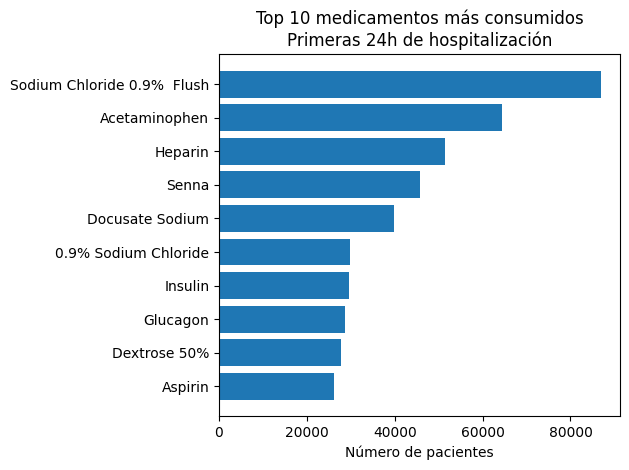

In [35]:
#Gráfico para ver el top medicamentos más consumidos (por número de pacientes, primeras 24h)

top_drugs = (
    rx_24h[["subject_id", "drug"]]
    .dropna()
    .drop_duplicates()
    .groupby("drug", as_index=False)
    .agg(n_patients=("subject_id", "nunique"))
    .sort_values("n_patients", ascending=False)
    .head(10)
    .sort_values("n_patients", ascending=True)
)

plt.figure()
plt.barh(
    top_drugs["drug"],
    top_drugs["n_patients"]
)
plt.xlabel("Número de pacientes")
plt.title("Top 10 medicamentos más consumidos\nPrimeras 24h de hospitalización")
plt.tight_layout()
plt.show()

# Identificación de comorbilidades predominantes

Esta sección se encarga de ver el top 5 de las comorbilidades más frecuentes en la población de personas con 60+ años. Para ello, lo que se hará es un filtro para usar solo los diagnósticos válidos, así se evitan los datos nulos. Luego de esto, se usará un contador para tener el número de cada enfermedad común, para luego hacer la selección de las 5 comorbilidades más frecuentes y guardarlas para el uso posterior.

In [36]:
#Conteo de diagnósticos (Top 5)

dx_counts = (
    dx_clean.groupby(["icd_code", "long_title"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top5_comorbidities = dx_counts.head(5).copy()

print("Top 5 comorbilidades:")
top5_comorbidities

Top 5 comorbilidades:


,icd_code,long_title,count
6531,E785,"Hyperlipidemia, unspecified",32078
8444,I10,Essential (primary) hypertension,29671
1832,4019,Unspecified essential hypertension,22361
17915,Z87891,Personal history of nicotine dependence,21242
9665,K219,Gastro-esophageal reflux disease without esoph...,16664


In [37]:
#Guardar Top 5

top5_comorbidities.to_parquet(
    os.path.join(OUT_DIR, "top5_comorbidities.parquet"),
    index=False
)

print("Top 5 comorbilidades guardadas en:", OUT_DIR)

Top 5 comorbilidades guardadas en: /content/outputs


In [38]:
#Flags Top 5 por paciente (1 fila por subject_id)

top5 = top5_comorbidities.copy()
top5["icd_code"] = top5["icd_code"].astype(str)
top5_codes = top5["icd_code"].tolist()

print("Top5 icd_code:", top5_codes)

dx_tmp = dx_clean.copy()
dx_tmp["icd_code"] = dx_tmp["icd_code"].astype(str)

#Presencia (0/1) por paciente y código del top 5
dx_top5_presence = (
    dx_tmp[dx_tmp["icd_code"].isin(top5_codes)][["subject_id", "icd_code"]]
    .drop_duplicates()
    .assign(value=1)
)

#Pivote a ancho, 1 fila por subject_id, columnas = icd_code
flags_top5_patient = (
    dx_top5_presence
    .pivot_table(
        index="subject_id",
        columns="icd_code",
        values="value",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

#Se asegura que existan todas las columnas del top5 (aunque alguna no aparezca)
for code in top5_codes:
    if code not in flags_top5_patient.columns:
        flags_top5_patient[code] = 0

print("flags_top5_patient:", flags_top5_patient.shape)
check_unique(flags_top5_patient, key="subject_id", name="flags_top5_patient")

flags_top5_patient.head()

Top5 icd_code: ['E785', 'I10', '4019', 'Z87891', 'K219']
flags_top5_patient: (76654, 6)
[flags_top5_patient] filas=76,654 | subject_id únicos=76,654
OK: flags_top5_patient es 1 fila por subject_id



icd_code,subject_id,4019,E785,I10,K219,Z87891
0,10000084,0,1,0,0,0
1,10000635,0,0,1,0,0
2,10000764,1,0,0,0,0
3,10000947,0,1,1,0,0
4,10000980,0,1,0,0,0


In [39]:
#Integración final comorbilidades (1 fila por subject_id)

patient_comorb = base_patient[["subject_id"]].merge(
    flags_top5_patient,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

#Rellenar NaN como 0 (no presenta comorbilidad)
for code in top5_codes:
    patient_comorb[code] = patient_comorb[code].fillna(0).astype(int)

print("patient_comorb:", patient_comorb.shape)
check_unique(patient_comorb, key="subject_id", name="patient_comorb")

patient_comorb.head()

patient_comorb: (111122, 6)
[patient_comorb] filas=111,122 | subject_id únicos=111,122
OK: patient_comorb es 1 fila por subject_id



,subject_id,4019,E785,I10,K219,Z87891
0,10000084,0,1,0,0,0
1,10000161,0,0,0,0,0
2,10000635,0,0,1,0,0
3,10000690,0,0,0,0,0
4,10000764,1,0,0,0,0


In [40]:
#Guardar outputs

patient_comorb.to_parquet(
    os.path.join(OUT_DIR, "patient_comorb_top5.parquet"),
    index=False
)

flags_top5_patient.to_parquet(
    os.path.join(OUT_DIR, "flags_top5_patient.parquet"),
    index=False
)

print("Fase 3 guardada en:", OUT_DIR)

Fase 3 guardada en: /content/outputs


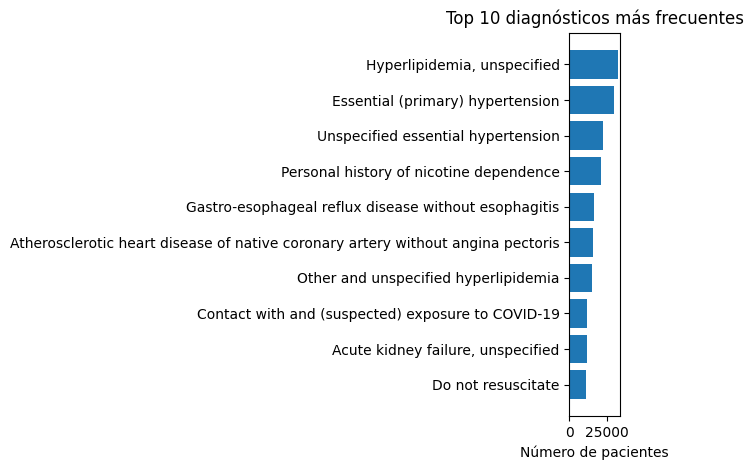

In [41]:
#Gráfico para ver el top 5 comorbilidades

top10 = dx_counts.head(10).sort_values("count", ascending=True)

plt.figure()
plt.barh(top10["long_title"], top10["count"])
plt.xlabel("Número de pacientes")
plt.title("Top 10 diagnósticos más frecuentes")
plt.tight_layout()
plt.show()

# Fusión de Notas Clínicas (Raw Data)

En esta sección se utilizan las notas clínicas en texto libre del módulo MIMIC-IV notes. Para ello, se vinculan las notas radiológicas a cada hospitalización usando hadm_id. Luego, se filtran solo las notas generadas dentro de las primeras 24 horas desde el ingreso hospitalario. Las notas seleccionadas se concatenan en un solo texto por hospitalización. El resultado de todo esto se guarda en formato Parquet para su uso posterior.

In [42]:
#Se hace una ventana 0–24h por paciente (hospitalización índice)

adm_window = base_keys[["subject_id", "hadm_id", "admittime"]].copy()
adm_window["admittime"] = pd.to_datetime(adm_window["admittime"], errors="coerce")

adm_window["t_start"] = adm_window["admittime"]
adm_window["t_end"]   = adm_window["admittime"] + pd.Timedelta(hours=24)

print("adm_window:", adm_window.shape)
check_unique(adm_window, key="subject_id", name="adm_window")

adm_window: (111122, 5)
[adm_window] filas=111,122 | subject_id únicos=111,122
OK: adm_window es 1 fila por subject_id



In [43]:
#Vincular a cohorte índice + filtrar 24h (sin choque de subject_id)

#Se debe asegurar que charttime sea datetime antes del filtro 0–24h
radiology["charttime"] = pd.to_datetime(radiology["charttime"], errors="coerce")

#Primero se queda solo con columnas necesarias de radiology (sin subject_id para evitar duplicados)
rad_base = radiology[["hadm_id", "charttime", "text"]].copy()

#Luego se debe vincular SOLO hospitalización índice y traer subject_id desde adm_window
rad_idx = rad_base.merge(
    adm_window[["subject_id", "hadm_id", "t_start", "t_end"]],
    on="hadm_id",
    how="inner",
    validate="many_to_one"   # adm_window tiene 1 fila por hadm_id
)

print("rad_idx (solo cohorte índice):", rad_idx.shape)

#Se filtra dentro de ventana 0–24h
rad_24h = rad_idx.loc[
    rad_idx["charttime"].notna() &
    (rad_idx["charttime"] >= rad_idx["t_start"]) &
    (rad_idx["charttime"] <= rad_idx["t_end"])
].copy()

print("rad_24h (notas en 24h):", rad_24h.shape)

#Printeos
rad_24h[["subject_id", "hadm_id", "charttime"]].head()

rad_idx (solo cohorte índice): (299995, 6)
rad_24h (notas en 24h): (64695, 6)


,subject_id,hadm_id,charttime
1,10000764,27897940.0,2132-10-15 09:02:00
2,10000980,20897796.0,2193-08-15 08:52:00
3,10000980,20897796.0,2193-08-15 19:28:00
8,10001667,22672901.0,2173-08-23 07:48:00
11,10001860,21441082.0,2188-03-27 01:56:00


In [44]:
#Concatenar todas las notas 24h por paciente + los carácteres correctos

rad_24h_sorted = rad_24h.sort_values(["subject_id", "charttime"]).copy()

notes_24h_concat = (
    rad_24h_sorted
    .groupby("subject_id")["text"]
    .apply(lambda x: "\n\n-----\n\n".join(x.dropna().astype(str)))
    .reset_index(name="notes_first24h_concat")
)

print("notes_24h_concat:", notes_24h_concat.shape)
check_unique(notes_24h_concat, key="subject_id", name="notes_24h_concat")

#Integrar con todos los pacientes (incluye los que no tienen notas -> NaN)
patient_notes_concat = base_patient[["subject_id"]].merge(
    notes_24h_concat,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

check_unique(patient_notes_concat, key="subject_id", name="patient_notes_concat")

#Cálculo correcto de largo de texto (NaN -> 0)
patient_notes_concat["n_chars_concat"] = (
    patient_notes_concat["notes_first24h_concat"]
    .fillna("")
    .astype(str)
    .str.len()
)

#Resumen de largos
patient_notes_concat["n_chars_concat"].describe()

#Cobertura real (cuántos pacientes tienen texto)
has_concat = patient_notes_concat["n_chars_concat"] > 0
print(f"Pacientes con notas CONCAT 24h: {has_concat.sum():,} / {len(patient_notes_concat):,} ({has_concat.mean():.1%})")

notes_24h_concat: (38989, 2)
[notes_24h_concat] filas=38,989 | subject_id únicos=38,989
OK: notes_24h_concat es 1 fila por subject_id

[patient_notes_concat] filas=111,122 | subject_id únicos=111,122
OK: patient_notes_concat es 1 fila por subject_id

Pacientes con notas CONCAT 24h: 38,989 / 111,122 (35.1%)


In [45]:
#Esto corresponde a las notas concatenadas

patient_notes_concat[
    patient_notes_concat["n_chars_concat"] > 0
][["subject_id", "notes_first24h_concat"]].head()

,subject_id,notes_first24h_concat
4,10000764,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
6,10000980,EXAMINATION: BILAT LOWER EXT VEINS\n\nINDICAT...
10,10001667,EXAMINATION: CT ANGIOGRAPHY HEAD AND NECK\n\n...
12,10001860,"HISTORY: Fall, evaluate for fracture.\n\nCOMP..."
14,10001884,INDICATION: Atraumatic pain.\n\nTECHNIQUE: O...


In [46]:
#Nota única 24h (PRIMERA) + carácteres correctos

#Orden por tiempo
rad_24h_sorted = rad_24h.sort_values(["subject_id", "charttime"]).copy()

#Tomar la PRIMERA nota en 24h por paciente
first_note_24h = (
    rad_24h_sorted
    .groupby("subject_id", as_index=False)
    .first()[["subject_id", "charttime", "text"]]
    .rename(columns={
        "charttime": "note_time_single",
        "text": "notes_first24h_single"
    })
)

print("first_note_24h:", first_note_24h.shape)
check_unique(first_note_24h, key="subject_id", name="first_note_24h")

#Unir con todos los pacientes (los que no tienen nota quedan como NaN)
patient_notes_single = base_patient[["subject_id"]].merge(
    first_note_24h,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

check_unique(patient_notes_single, key="subject_id", name="patient_notes_single")

#Cálculo correcto de largo de texto (NaN -> 0)
patient_notes_single["n_chars_single"] = (
    patient_notes_single["notes_first24h_single"]
    .fillna("")
    .astype(str)
    .str.len()
)

#Resumen de largos
patient_notes_single["n_chars_single"].describe()

#Cobertura real
has_single = patient_notes_single["n_chars_single"] > 0
print(
    f"Pacientes con nota ÚNICA 24h: "
    f"{has_single.sum():,} / {len(patient_notes_single):,} "
    f"({has_single.mean():.1%})"
)

first_note_24h: (38989, 3)
[first_note_24h] filas=38,989 | subject_id únicos=38,989
OK: first_note_24h es 1 fila por subject_id

[patient_notes_single] filas=111,122 | subject_id únicos=111,122
OK: patient_notes_single es 1 fila por subject_id

Pacientes con nota ÚNICA 24h: 38,989 / 111,122 (35.1%)


In [47]:
#Esto corresponde a las notas únicas

patient_notes_single[
    patient_notes_single["n_chars_single"] > 0
][["subject_id", "note_time_single", "notes_first24h_single"]].head()

,subject_id,note_time_single,notes_first24h_single
4,10000764,2132-10-15 09:02:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
6,10000980,2193-08-15 08:52:00,EXAMINATION: BILAT LOWER EXT VEINS\n\nINDICAT...
10,10001667,2173-08-23 07:48:00,EXAMINATION: CT ANGIOGRAPHY HEAD AND NECK\n\n...
12,10001860,2188-03-27 01:56:00,"HISTORY: Fall, evaluate for fracture.\n\nCOMP..."
14,10001884,2131-01-08 09:36:00,INDICATION: Atraumatic pain.\n\nTECHNIQUE: O...


In [50]:
#Cobertura de notas

#Identifica pacientes que tienen al menos una nota clínica válida dentro de las primeras 24 horas, usando la versión concatenada
has_concat = patient_notes_concat["notes_first24h_concat"].notna() & (patient_notes_concat["n_chars_concat"] > 0)

#Identifica pacientes que tienen una nota clínica válida usando la representación de nota única (primera nota en 24h)
has_single = patient_notes_single["notes_first24h_single"].notna() & (patient_notes_single["n_chars_single"] > 0)

print(f"Pacientes totales: {len(base_patient):,}")
print(f"Con notas CONCAT 24h: {has_concat.sum():,} ({has_concat.mean():.1%})")
print(f"Con nota ÚNICA 24h : {has_single.sum():,} ({has_single.mean():.1%})")

Pacientes totales: 111,122
Con notas CONCAT 24h: 38,989 (35.1%)
Con nota ÚNICA 24h : 38,989 (35.1%)


In [51]:
#Guardar notas (ambas versiones, concatenadas y únicas)

OUT_NOTES_CONCAT = os.path.join(OUT_DIR, "patient_notes_concat_24h.parquet")
OUT_NOTES_SINGLE = os.path.join(OUT_DIR, "patient_notes_single_24h.parquet")

patient_notes_concat.drop(columns=["n_chars_concat"], errors="ignore").to_parquet(OUT_NOTES_CONCAT, index=False)
patient_notes_single.drop(columns=["n_chars_single"], errors="ignore").to_parquet(OUT_NOTES_SINGLE, index=False)

print("Notas guardadas:")
print(" -", OUT_NOTES_CONCAT)
#print(" -", OUT_NOTES_SINGLE)

Notas guardadas:
 - /content/outputs/patient_notes_concat_24h.parquet


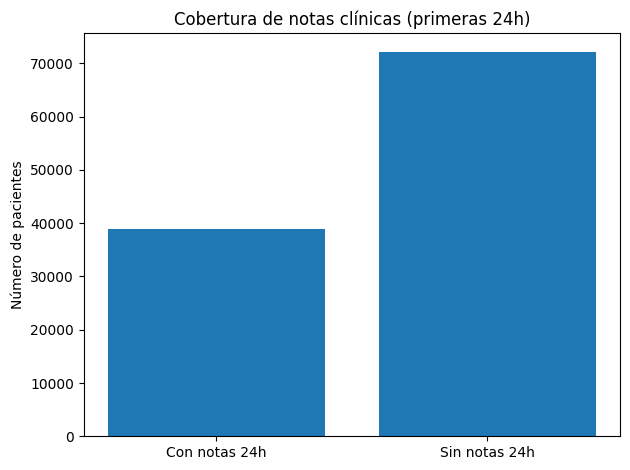

In [52]:
#Gráfico para ver cuantos pacientes tienen texto clínico

notes_coverage = [
    has_concat.sum(),
    len(base_patient) - has_concat.sum()
]

plt.figure()
plt.bar(
    ["Con notas 24h", "Sin notas 24h"],
    notes_coverage
)
plt.ylabel("Número de pacientes")
plt.title("Cobertura de notas clínicas (primeras 24h)")
plt.tight_layout()
plt.show()

# Modelado de Supervivencia (Kaplan-Meier)

Para esta sección se construyó un dataset con el tiempo hasta muerte o alta hospitalaria y el indicador de evento. A su vez, se definió la mortalidad intrahospitalaria como evento y la duración desde el ingreso como tiempo de seguimiento. Se dividieron las hospitalizaciones en 2 grupos, uno con comorbilidad y otro sin, permitiendo comparar la supervivencia entre ambos Para cada comorbilidad se estimaron curvas de supervivencia Kaplan-Meier. Además, se visualizaron curvas de riesgo acumulado para comparar el impacto de las comorbilidades en la mortalidad.

In [55]:
#Dataset de supervivencia (1 fila por subject_id)

surv_patient = base_patient[
    ["subject_id", "admittime", "dischtime", "deathtime", "hospital_expire_flag"]
].copy()

for c in ["admittime", "dischtime", "deathtime"]:
    surv_patient[c] = pd.to_datetime(surv_patient[c], errors="coerce")

#Evento, muerte intrahospitalaria (1) vs censura (0)
surv_patient["event"] = surv_patient["hospital_expire_flag"].fillna(0).astype(int)

#Endtime, muerte si ocurrió, si no es alta
surv_patient["endtime"] = surv_patient["deathtime"].where(
    surv_patient["event"] == 1,
    surv_patient["dischtime"]
)

#Tiempo hasta evento/censura en días
surv_patient["time_days"] = (
    surv_patient["endtime"] - surv_patient["admittime"]
).dt.total_seconds() / (3600 * 24)

#Filtrar casos inválidos
surv_patient = surv_patient[
    surv_patient["time_days"].notna() & (surv_patient["time_days"] >= 0)
].copy()

print("surv_patient:", surv_patient.shape)
check_unique(surv_patient, key="subject_id", name="surv_patient")
surv_patient[["event", "time_days"]].describe()

surv_patient: (111090, 8)
[surv_patient] filas=111,090 | subject_id únicos=111,090
OK: surv_patient es 1 fila por subject_id



,event,time_days
count,111090.000000,111090.000000
mean,0.084067,5.731583
std,0.277489,7.891063
min,0.000000,0.000000
25%,0.000000,1.618056
50%,0.000000,3.603472
75%,0.000000,6.853472
max,1.000000,248.448611


In [56]:
#Unir comorbilidades Top 5

#top5_codes y code_to_title vienen desde Fase 3
top5 = top5_comorbidities.copy()
top5["icd_code"] = top5["icd_code"].astype(str)
top5_codes = top5["icd_code"].tolist()

code_to_title = top5.set_index("icd_code")["long_title"].to_dict()

km_df = surv_patient.merge(
    patient_comorb,
    on="subject_id",
    how="left",
    validate="one_to_one"
)

#Asegurar columnas top5 como 0/1
for code in top5_codes:
    if code not in km_df.columns:
        km_df[code] = 0
    km_df[code] = km_df[code].fillna(0).astype(int)

print("km_df:", km_df.shape)
check_unique(km_df, key="subject_id", name="km_df")
km_df[["subject_id", "event", "time_days"] + top5_codes].head()

km_df: (111090, 13)
[km_df] filas=111,090 | subject_id únicos=111,090
OK: km_df es 1 fila por subject_id



,subject_id,event,time_days,E785,I10,4019,Z87891,K219
0,10000084,0,0.455556,1,0,0,0,0
1,10000161,0,0.618750,0,0,0,0,0
2,10000635,0,0.914583,0,1,0,0,0
3,10000690,0,1.677778,0,0,0,0,0
4,10000764,0,4.707639,0,0,1,0,0


In [57]:
#Guardar dataset final

km_df.to_parquet(
    os.path.join(OUT_DIR, "km_df_top5.parquet"),
    index=False
)

#Printeo de confirmación
print("km_df_top5.parquet guardado en:", OUT_DIR)

km_df_top5.parquet guardado en: /content/outputs


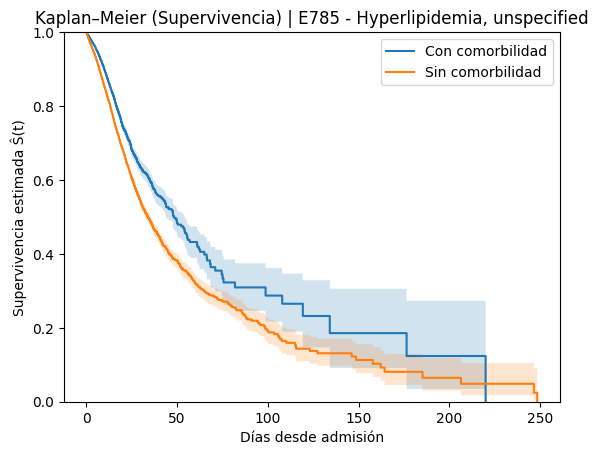

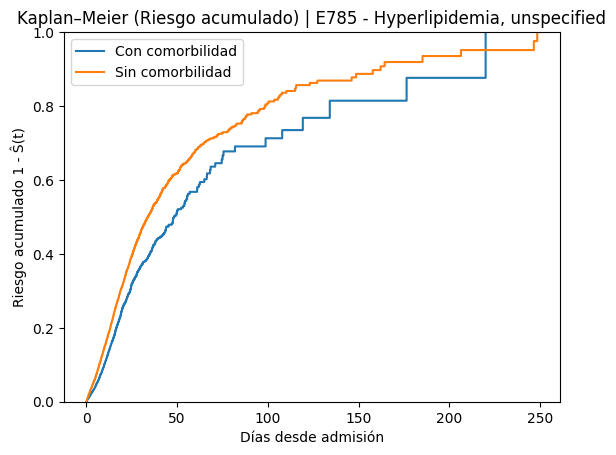

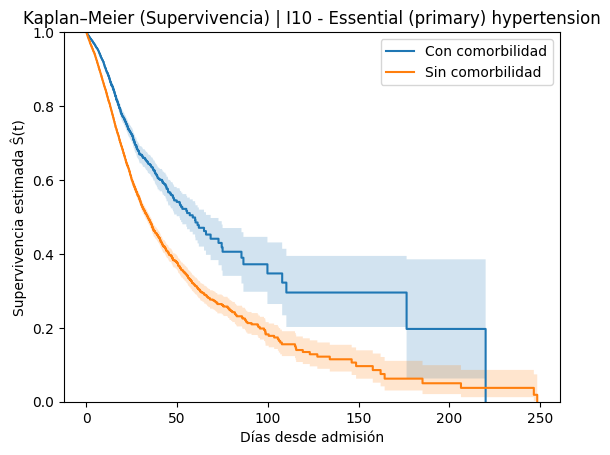

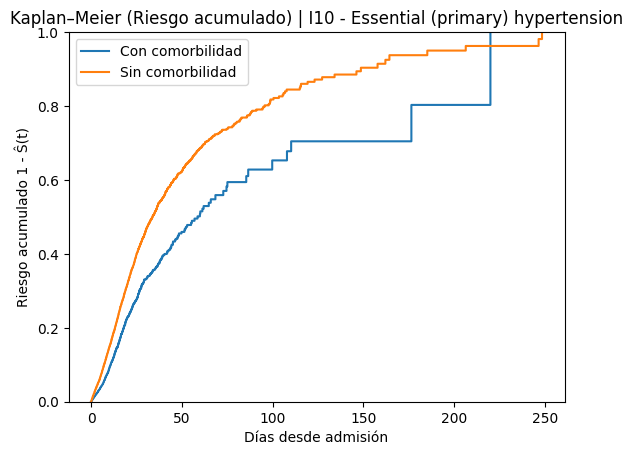

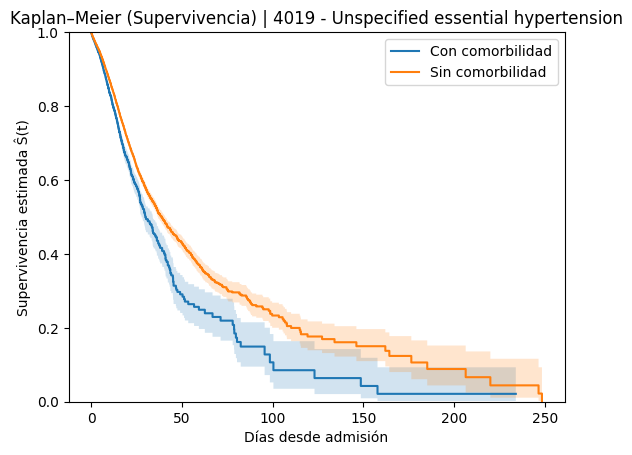

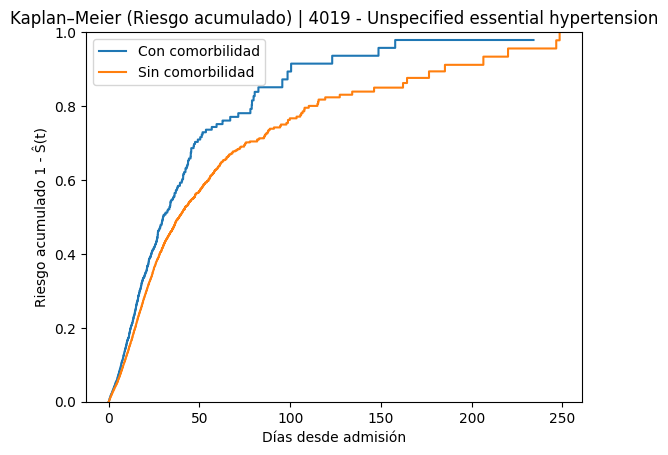

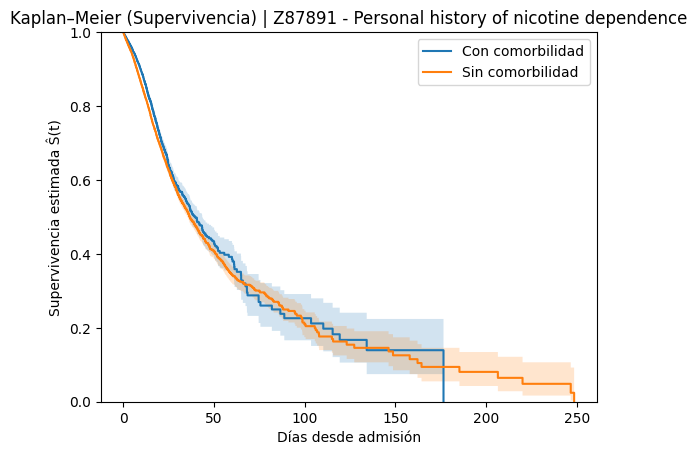

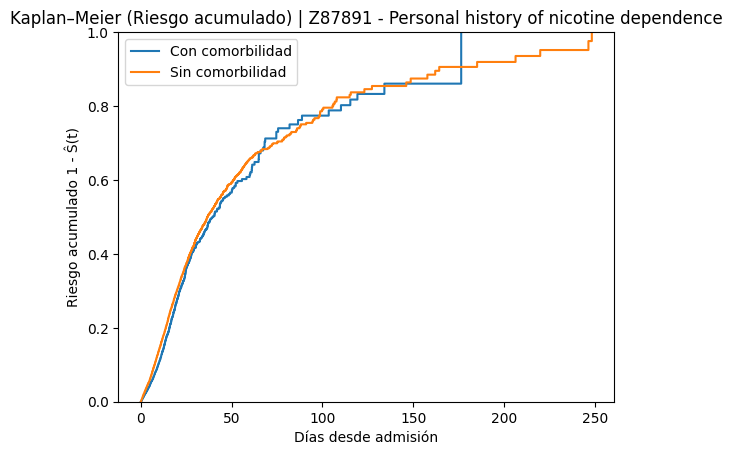

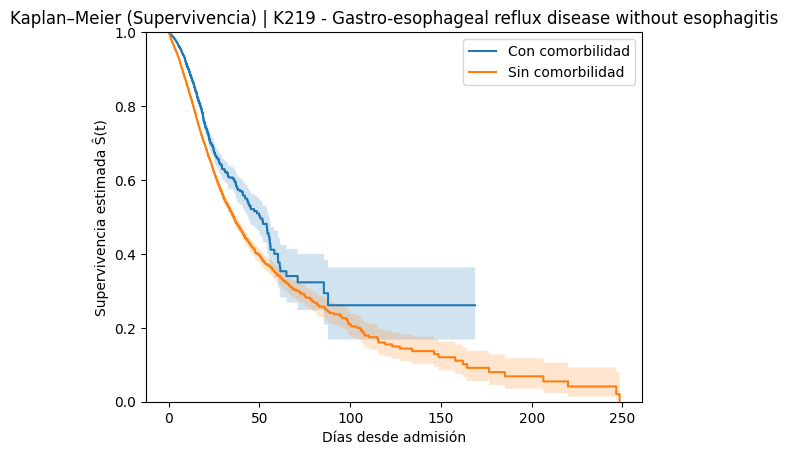

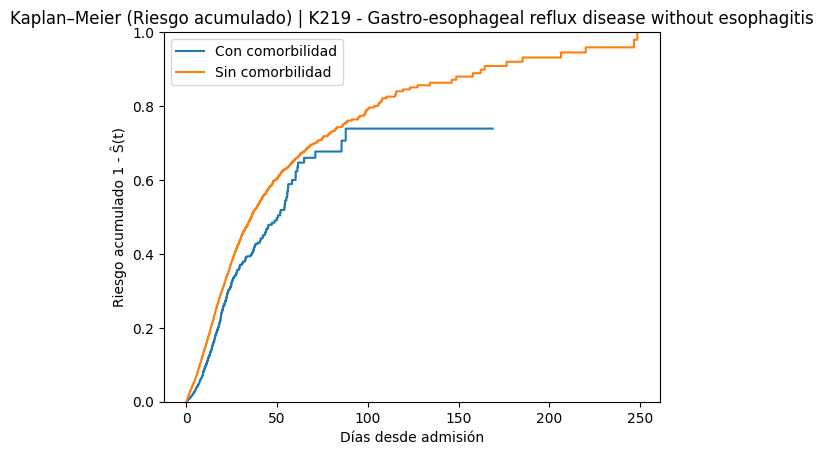

In [59]:
#Kaplan–Meier por comorbilidad (Top5)

#Se itera sobre cada código ICD correspondiente a las 5 comorbilidades más frecuentes
for code in top5_codes:

    #Grupo de pacientes CON la comorbilidad (flag = 1)
    g1 = km_df[km_df[code] == 1]

    #Grupo de pacientes SIN la comorbilidad (flag = 0)
    g0 = km_df[km_df[code] == 0]

    #Si alguno de los grupos está vacío, no se puede estimar la curva
    if len(g1) == 0 or len(g0) == 0:
        print(f"Saltado {code}: grupo vacío (con={len(g1)}, sin={len(g0)})")
        continue

    #Estimación Kaplan–Meier para pacientes CON la comorbilidad
    #event: indica si ocurrió el evento (muerte intrahospitalaria)
    #time_days: tiempo hasta evento o censura
    #conf_type="log-log": intervalos de confianza estándar para KM
    t1, s1, ci1 = kaplan_meier_estimator(
        g1["event"].astype(bool),
        g1["time_days"],
        conf_type="log-log"
    )

    #Estimación Kaplan–Meier para pacientes SIN la comorbilidad
    t0, s0, ci0 = kaplan_meier_estimator(
        g0["event"].astype(bool),
        g0["time_days"],
        conf_type="log-log"
    )

    #Título del gráfico
    title = f"{code} - {code_to_title.get(code, '')}"

    plt.figure()
    plt.step(t1, s1, where="post", label="Con comorbilidad")
    plt.step(t0, s0, where="post", label="Sin comorbilidad")
    plt.fill_between(t1, ci1[0], ci1[1], alpha=0.2, step="post")
    plt.fill_between(t0, ci0[0], ci0[1], alpha=0.2, step="post")
    plt.ylim(0, 1)
    plt.xlabel("Días desde admisión")
    plt.ylabel("Supervivencia estimada Ŝ(t)")
    plt.title(f"Kaplan–Meier (Supervivencia) | {title}")
    plt.legend()
    plt.show()

    #El riesgo acumulado se define como 1 - Ŝ(t)
    plt.figure()
    plt.step(t1, 1 - s1, where="post", label="Con comorbilidad")
    plt.step(t0, 1 - s0, where="post", label="Sin comorbilidad")
    plt.ylim(0, 1)
    plt.xlabel("Días desde admisión")
    plt.ylabel("Riesgo acumulado 1 - Ŝ(t)")
    plt.title(f"Kaplan–Meier (Riesgo acumulado) | {title}")
    plt.legend()
    plt.show()

# Creación variable objetivo - Evento coronario agudo

Este bloque corresponde a la creación de la primera variable objetivo, el evento coronario agudo.
Para ello, se usará una columna binaria, en donde el número 1 representa que tuvo el evento coronario agudo en la hospitalización. En caso contrario, es decir, que no tuvo el evento, será representado con el número 0.

In [60]:
#Outcome (Evento coronario agudo)

#Se aseguran tipos consistentes (para que los filtros por prefijo funcionen bien)
dx_tmp = dx_clean[["subject_id", "icd_code", "icd_version"]].copy()  #Se hace una copia para no usar dx_clean
dx_tmp["icd_code"] = dx_tmp["icd_code"].astype(str) #Necesario para usar .str.startswith()
dx_tmp["icd_version"] = pd.to_numeric(dx_tmp["icd_version"], errors="coerce") #Convertir a numérico. Si hay basura = queda como NaN

#ICD-10: Infarto agudo (I21), subsecuente (I22), complicaciones (I23), otros SCA (I24) (síndrome coronario agudo)
icd10_acs_prefixes = ("I21", "I22", "I23", "I24")

#ICD-9: Infarto agudo (410), otros relacionados agudos (411)
icd9_acs_prefixes = ("410", "411")

#Máscaras booleanas, las cuales detectan diagnósticos que empiezan por esos prefijos según versión ICD
is_acs_icd10 = (dx_tmp["icd_version"] == 10) & dx_tmp["icd_code"].str.startswith(icd10_acs_prefixes)
is_acs_icd9  = (dx_tmp["icd_version"] == 9)  & dx_tmp["icd_code"].str.startswith(icd9_acs_prefixes)

#Se quedan los subject_id que cumplen ACS (síndrome coronario agudo) al menos una vez (sin duplicarse)
dx_acs = dx_tmp[is_acs_icd10 | is_acs_icd9][["subject_id"]].drop_duplicates()
dx_acs["target_coronary_acute"] = 1  #Etiqueta binaria: si aparece aquí, el outcome es 1

#Base 1 fila por paciente, se hace left join para conservar todos los pacientes
outcome_coronary = base_patient[["subject_id"]].merge(
    dx_acs,
    on="subject_id",
    how="left",
    validate="one_to_one" #1 fila por subject_id
)

#Rellenar NaN -> 0 (pacientes sin el evento coronario y derivados) y dejar como int
outcome_coronary["target_coronary_acute"] = (
    outcome_coronary["target_coronary_acute"].fillna(0).astype(int)
)

#Validación para que quede exactamente 1 fila por subject_id
check_unique(outcome_coronary, key="subject_id", name="outcome_coronary")

#Prevalencia rápida del outcome (proporción de 0 y 1)
outcome_coronary["target_coronary_acute"].value_counts(normalize=True)

[outcome_coronary] filas=111,122 | subject_id únicos=111,122
OK: outcome_coronary es 1 fila por subject_id



,proportion
target_coronary_acute,
0,0.927008
1,0.072992


In [61]:
#Guardado

outcome_coronary.to_parquet(
    os.path.join(OUT_DIR, "outcome_coronary_acute.parquet"),
    index=False
)

print("Outcome coronario agudo guardado en:", OUT_DIR)

Outcome coronario agudo guardado en: /content/outputs


# Creación variable objetivo - Mortalidad intrahospitalaria

In [62]:
#Outcome (Mortalidad intrahospitalaria)

outcome_death = base_patient[["subject_id", "hospital_expire_flag"]].copy()

#Asegurar binario 0/1
outcome_death["target_death_inhospital"] = (
    outcome_death["hospital_expire_flag"].fillna(0).astype(int)
)

#Quedarse solo con lo necesario
outcome_death = outcome_death[["subject_id", "target_death_inhospital"]].copy()

#Validación obligatoria: 1 fila por paciente
check_unique(outcome_death, key="subject_id", name="outcome_death")

#Prevalencia rápida
outcome_death["target_death_inhospital"].value_counts(normalize=True)

[outcome_death] filas=111,122 | subject_id únicos=111,122
OK: outcome_death es 1 fila por subject_id



,proportion
target_death_inhospital,
0,0.915732
1,0.084268


In [63]:
#Guardado

outcome_death.to_parquet(
    os.path.join(OUT_DIR, "outcome_death_inhospital.parquet"),
    index=False
)

print("Outcome mortalidad guardado en:", OUT_DIR)

Outcome mortalidad guardado en: /content/outputs


# Unión de ambos outcomes

In [64]:
#Unir ambos outcomes
outcomes = (
    outcome_coronary
    .merge(
        outcome_death,
        on="subject_id",
        how="inner",
        validate="one_to_one"
    )
)

#Tabla de contingencia
pd.crosstab(
    outcomes["target_coronary_acute"],
    outcomes["target_death_inhospital"],
    rownames=["Evento coronario"],
    colnames=["Muerte intrahospitalaria"]
)

Muerte intrahospitalaria,0,1
Evento coronario,,
0,95263,7748
1,6495,1616


<Figure size 640x480 with 0 Axes>

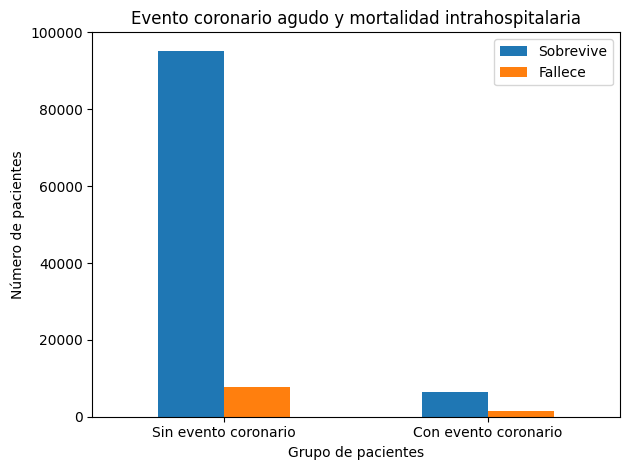

In [65]:
#Datos desde la tabla de contingencia
data = pd.DataFrame(
    {
        "Sobrevive": [95263, 6495],
        "Fallece": [7748, 1616]
    },
    index=["Sin evento coronario", "Con evento coronario"]
)

#Gráfico de barras
plt.figure()
data.plot(kind="bar")
plt.xlabel("Grupo de pacientes")
plt.ylabel("Número de pacientes")
plt.title("Evento coronario agudo y mortalidad intrahospitalaria")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

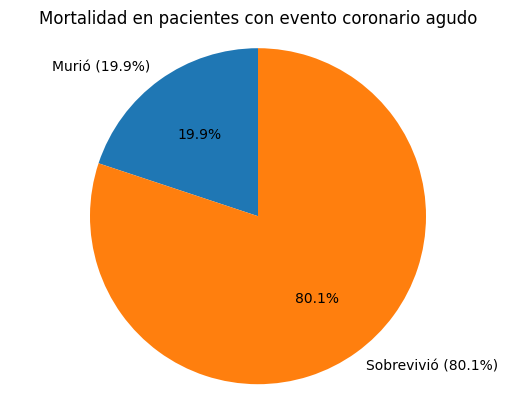

In [66]:
#Porcentajes
sizes = [19.9, 80.1]
labels = ["Murió (19.9%)", "Sobrevivió (80.1%)"]

plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Mortalidad en pacientes con evento coronario agudo")
plt.axis("equal")
plt.show()

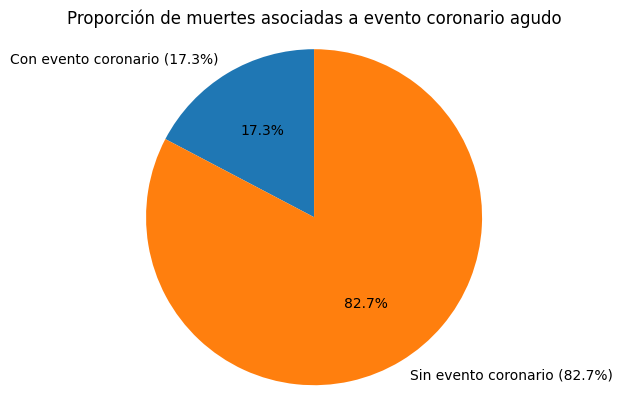

In [67]:
#Porcentajes
sizes = [17.3, 82.7]
labels = ["Con evento coronario (17.3%)", "Sin evento coronario (82.7%)"]

plt.figure()
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporción de muertes asociadas a evento coronario agudo")
plt.axis("equal")
plt.show()